In [3]:
import os
import sys

import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.gErrorIgnoreLevel = ROOT.kWarning

print("ROOT loaded successfully")
print(f"ROOT version: {ROOT.gROOT.GetVersion()}")

# Path to the NanoAOD file to analyze. Change this to point at your own file.
FILE_PATH = "examples/test.root"

assert os.path.exists(FILE_PATH), f"File not found: {FILE_PATH}"
print(f"Using input file: {FILE_PATH}")


ROOT loaded successfully
ROOT version: 6.40.00
Using input file: examples/test.root


In [4]:
# Import the analysis toolkit modules
from analyze_root import analyze_root_file
from analyze_proton_events import PPSHistogramType, create_histograms_and_plots

from IPython.display import Image, display


## 2. ROOT file inspection (`analyze_root.py`)

Before filtering or histogramming anything, it's useful to know **what data
is actually available** in the file. `analyze_root_file()` opens the file,
lists its trees, and scans the `Events` tree for any branch whose name
matches `*PPS*` or `*proton*` (case-insensitive).

### PPS / proton data collections

| Collection | Description |
|---|---|
| `PPSLocalTrack` | Local track reconstructed in a single Roman Pot detector (position, time, RP id, RP type) |
| `Proton_multiRP` | Proton kinematics reconstructed using tracks from *multiple* Roman Pots in the same arm (more precise: gives ξ, t, θx, θy) |
| `Proton_singleRP` | Proton kinematics reconstructed from a *single* Roman Pot track (less precise, but available even when only one RP has a track) |
| `HLT_PPS*` / `HLT_*PPSMatch*` | High-Level Trigger decisions related to PPS |

### Discovered variables (25 total, from the example file)

- **HLT Triggers** (4): `DiPFJetAve180_PPSMatch`, `PPSMaxTracksPerArm1`, `PPSMaxTracksPerRP4`, `PPSRandom`
- **PPSLocalTrack** (9): `x`, `y`, `decRPId`, `rpType`, `multiRPProtonIdx`, `singleRPProtonIdx`, `time`, `timeUnc`, `nPPSLocalTrack`
- **Proton_multiRP** (8): `arm`, `t`, `thetaX`, `thetaY`, `time`, `timeUnc`, `xi`, `nProton_multiRP`
- **Proton_singleRP** (4): `decRPId`, `thetaY`, `xi`, `nProton_singleRP`

Run the cell below to print the full variable list, their types, and the
values for the first 5 events. A detailed report is also written to
`result_with_protons.txt`.


In [5]:
analyze_root_file(FILE_PATH)


Warning in <TClass::Init>: no dictionary for class edm::Hash<1> is available
Warning in <TClass::Init>: no dictionary for class edm::ParameterSetBlob is available
Warning in <TClass::Init>: no dictionary for class edm::ProcessHistory is available
Warning in <TClass::Init>: no dictionary for class edm::ProcessConfiguration is available
Warning in <TClass::Init>: no dictionary for class pair<edm::Hash<1>,edm::ParameterSetBlob> is available


=== NanoAOD Analysis: examples/test.root ===

Objects in ROOT file:

Found trees: ['Events', 'LuminosityBlocks', 'Runs', 'MetaData', 'ParameterSets']

Tree 'Events': 346825 events
TFile**		examples/test.root	
 TFile*		examples/test.root	
  KEY: TObjString	tag;1	Collectable string class
  KEY: TTree	Events;1	Events
  KEY: TTree	LuminosityBlocks;1	LuminosityBlocks
  KEY: TTree	Runs;1	Runs
  KEY: TTree	MetaData;1	Job metadata
  KEY: TTree	ParameterSets;1	Parameter sets
Tree 'LuminosityBlocks': 71 events
Tree 'Runs': 1 events
Tree 'MetaData': 1 events
Tree 'ParameterSets': 14239 events

Total events in all trees: 361137

--------------------------------------------------------------------------------

=== PPS & Proton Variables Analysis (regex: *PPS* OR *proton*) ===
Found PPS & Proton variables (25):

   1. HLT_DiPFJetAve180_PPSMatch_Xi0p3_QuadJet_Max2ProtPerRP
   2. HLT_PPSMaxTracksPerArm1
   3. HLT_PPSMaxTracksPerRP4
   4. HLT_PPSRandom
   5. PPSLocalTrack_decRPId
   6. PPSLocalTrack_mu

In [6]:
def rdata_analysis(file_path, filter_funcs=None):
    """
    RDataFrame analysis of PPS data - filtering, statistics, parallel processing

    Args:
        file_path: Path to ROOT file
        filter_funcs: List of filter functions to apply (optional)
                     Each function should take df and return filtered df
    """
    print("=== RDataFrame PPS Analysis ===")
    print(f"Analyzing file: {file_path}")
    print()

    df = ROOT.RDataFrame("Events", file_path)

    print(f"Total events in file: {df.Count().GetValue()}")

    # Filter events with at least one PPS track - a Must Have
    df_with_pps = df.Filter("nPPSLocalTrack > 0")
    events_with_pps = df_with_pps.Count().GetValue()

    print(f"Events with PPS data: {events_with_pps}")
    print()

    # Apply custom filters if provided
    if filter_funcs:
        print("=== Applying Custom Filters ===")
        df_filtered = df_with_pps

        for i, filter_func in enumerate(filter_funcs):
            print(f"Applying filter {i + 1}: {filter_func.__name__}")
            df_filtered = filter_func(df_filtered)
            count = df_filtered.Count().GetValue()
            print(f"  Events after filter: {count}")

        print()
        print("=== Filter Results ===")
        print(f"Events after all filters: {df_filtered.Count().GetValue()}")
        print()
    else:
        # No filters applied - use all PPS events
        df_filtered = df_with_pps

    return df_filtered


In [7]:
# Build the RDataFrame with no custom filters. This reports total events and
# events-with-PPS-data counts.

df_baseline = rdata_analysis(FILE_PATH)


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565



In [8]:
# Implementations of the filter functions. Each takes an
# RDataFrame and returns a new, filtered RDataFrame.
def filter_double_arm_events(df):
    """
    Select events with tracks in both arms:
    - Left arm: RP ID 23 or 123
    - Right arm: RP ID 3 or 103
    """
    df_filtered = df.Filter(
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 23 || PPSLocalTrack_decRPId == 123)) && "
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 3 || PPSLocalTrack_decRPId == 103))",
        "Events with tracks in both arms (23|123) and (3|103)"
    )
    return df_filtered


def filter_single_arm_events(df):
    """
    Select events with tracks in only one arm (left OR right, but not both)
    """
    df_filtered = df.Filter(
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 23 || PPSLocalTrack_decRPId == 123)) != "
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 3 || PPSLocalTrack_decRPId == 103))",
        "Events with tracks in only one arm"
    )
    return df_filtered


def filter_detector_specific_events(df, rp_id):
    """
    Select events with tracks in specific Roman Pot detector
    """
    filter_expr = f"ROOT::VecOps::Any(PPSLocalTrack_decRPId == {rp_id})"
    df_filtered = df.Filter(filter_expr, f"Events with tracks in RP {rp_id}")
    return df_filtered


def filter_xi_ranged_events(df, xi_min, xi_max):
    """
    Select events with proton fractional momentum loss in specified range.

    Prefers PPSLocalTrack_xi (original per-track logic) if that column is
    present in the file; falls back to Proton_multiRP_xi (multi-RP proton
    reconstruction) only if PPSLocalTrack_xi doesn't exist.
    """
    available_columns = [str(c) for c in df.GetColumnNames()]
    xi_column = "PPSLocalTrack_xi" if "PPSLocalTrack_xi" in available_columns else "Proton_multiRP_xi"

    filter_expr = f"ROOT::VecOps::Any({xi_column} >= {xi_min} && {xi_column} <= {xi_max})"
    df_filtered = df.Filter(filter_expr, f"Events with xi in [{xi_min}, {xi_max}] (using {xi_column})")
    return df_filtered


def filter_detector_type(df, detector_type):
    """
    Select events with tracks in specific detector type using PPSLocalTrack_rpType

    Args:
        df: RDataFrame
        detector_type: 'pixel' for silicon pixel detectors (rpType = 4)
                      'diamond' for diamond timing detectors (rpType = 5)

    Returns:
        Filtered RDataFrame
    """
    detector_type_map = {
        'pixel': 4,
        'diamond': 5
    }

    if detector_type.lower() not in detector_type_map:
        raise ValueError(f"Unknown detector type '{detector_type}'. Use 'pixel' or 'diamond'.")

    rp_type = detector_type_map[detector_type.lower()]
    filter_expr = f"ROOT::VecOps::Any(PPSLocalTrack_rpType == {rp_type})"

    df_filtered = df.Filter(filter_expr, f"Events with {detector_type} detector tracks (rpType={rp_type})")
    return df_filtered


In [9]:
# Single arm: tracks in only one arm (left OR right, not both)
df_single_arm = filter_single_arm_events(df_baseline)
print("Single-arm events:", df_single_arm.Count().GetValue())

Single-arm events: 34828


In [10]:
# Double arm: tracks in both arms simultaneously
df_double_arm = filter_double_arm_events(df_baseline)
print("Double-arm events:", df_double_arm.Count().GetValue())


Double-arm events: 276737


In [11]:
# Detector-specific: only events with a track in a given Roman Pot (e.g. RP 23)
df_rp23 = filter_detector_specific_events(df_baseline, rp_id=23)
print("Events with RP 23 tracks:", df_rp23.Count().GetValue())


Events with RP 23 tracks: 218743


In [12]:
# Detector type: pixel (rpType=4) vs diamond timing (rpType=5) detectors
df_pixel = filter_detector_type(df_baseline, "pixel")
print("Events with pixel-detector tracks:", df_pixel.Count().GetValue())

df_diamond = filter_detector_type(df_baseline, "diamond")
print("Events with diamond-detector tracks:", df_diamond.Count().GetValue())


Events with pixel-detector tracks: 311565
Events with diamond-detector tracks: 75275


In [13]:
# Xi range: proton fractional momentum loss in [xi_min, xi_max]
df_xi_range = filter_xi_ranged_events(df_baseline, xi_min=0.05, xi_max=0.2)
print("Events with xi in [0.05, 0.2]:", df_xi_range.Count().GetValue())


Events with xi in [0.05, 0.2]: 121461


### Combining multiple filters

`rdata_analysis()` accepts a **list** of filter functions, applied in
sequence (logical AND). Filters requiring extra arguments (like
`filter_detector_specific_events` or `filter_xi_ranged_events`) can be
wrapped in a `lambda`:

```python
filters = [
    filter_double_arm_events,
    lambda df: filter_detector_type(df, "pixel"),
    lambda df: filter_xi_ranged_events(df, 0.05, 0.2),
]
df_filtered = rdata_analysis(FILE_PATH, filters)
```


In [14]:
filters = [
    filter_double_arm_events,
    lambda df: filter_detector_type(df, "pixel"),
]
df_filtered = rdata_analysis(FILE_PATH, filters)


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: filter_double_arm_events
  Events after filter: 276737
Applying filter 2: <lambda>
  Events after filter: 276737

=== Filter Results ===
Events after all filters: 276737



## 4. Histogram generation

All 25 PPS/proton variables are exposed as members of the `PPSHistogramType`
enum. `create_histograms_and_plots()` books a `Histo1D` (or `Histo2D`, for
X-vs-Y track positions) for each requested type, saves them to a ROOT file
under `data/`, and renders each one as a PNG plot.

### Variable groups

- **Track variables**: `N_PPS_LOCAL_TRACK`, `PPS_LOCAL_TRACK_X`, `PPS_LOCAL_TRACK_Y`,
  `PPS_LOCAL_TRACK_DEC_RP_ID`, `PPS_LOCAL_TRACK_RP_TYPE`, `PPS_LOCAL_TRACK_TIME`,
  `PPS_LOCAL_TRACK_TIME_UNC`, `PPS_LOCAL_TRACK_MULTI_RP_PROTON_IDX`,
  `PPS_LOCAL_TRACK_SINGLE_RP_PROTON_IDX`
- **Multi-RP proton variables**: `N_PROTON_MULTI_RP`, `PROTON_MULTI_RP_ARM`,
  `PROTON_MULTI_RP_T`, `PROTON_MULTI_RP_THETA_X`, `PROTON_MULTI_RP_THETA_Y`,
  `PROTON_MULTI_RP_TIME`, `PROTON_MULTI_RP_TIME_UNC`, `PROTON_MULTI_RP_XI`
- **Single-RP proton variables**: `N_PROTON_SINGLE_RP`,
  `PROTON_SINGLE_RP_DEC_RP_ID`, `PROTON_SINGLE_RP_THETA_Y`, `PROTON_SINGLE_RP_XI`
- **HLT triggers**: `HLT_PPSMaxTracksPerArm1`, `HLT_PPSMaxTracksPerRP4`,
  `HLT_PPSRandom`, `HLT_DiPFJetAve180_PPSMatch_Xi0p3_QuadJet_Max2ProtPerRP`

> When both `PPS_LOCAL_TRACK_X` and `PPS_LOCAL_TRACK_Y` are requested, a 2D
> X-vs-Y correlation histogram is automatically created as well.


In [15]:
# Choose which histograms to generate — edit this list freely.
histogram_types = [
    PPSHistogramType.PPS_LOCAL_TRACK_X,
    PPSHistogramType.PPS_LOCAL_TRACK_Y,
]

histograms = create_histograms_and_plots(
    df_single_arm,
    histogram_types,
    output_prefix="pps_single_arm",
)


=== Creating Histograms ===
Creating histogram for: PPSLocalTrack_x
Creating histogram for: PPSLocalTrack_y
Creating 2D histogram: X vs Y
Created 3 histogram(s)

Saving histograms to: data/pps_single_arm.root
Histograms saved!

=== Creating Plots ===
Saved: data/pps_single_arm_track_x.png
Saved: data/pps_single_arm_track_y.png
Saved: data/pps_single_arm_xy.png

=== Histogram Creation Complete ===


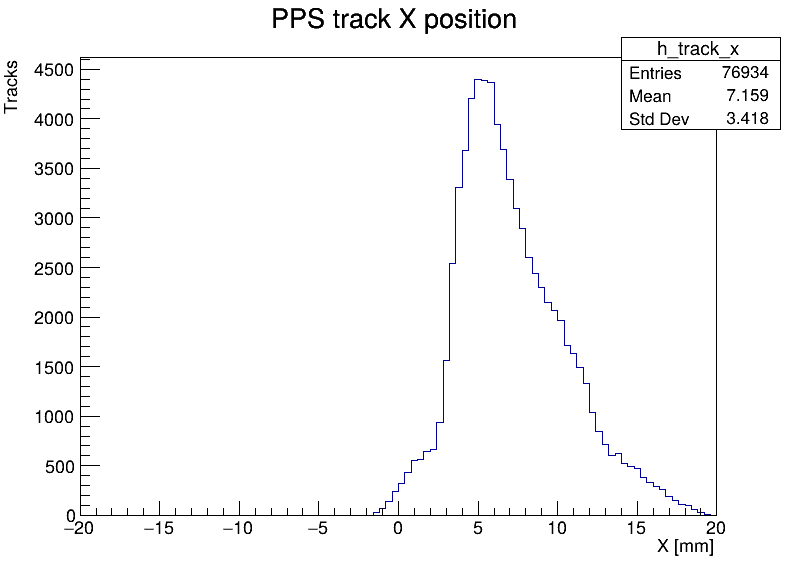

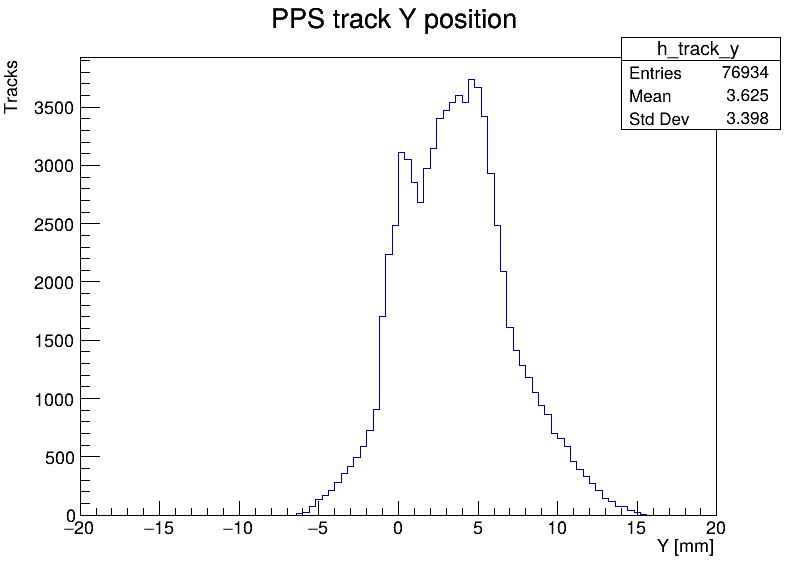

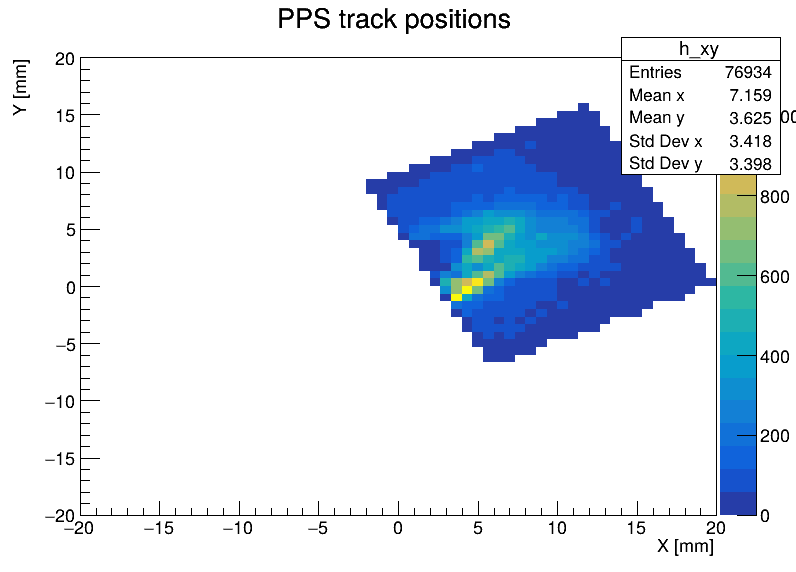

In [16]:
# Display the generated plots inline.
for name in histograms:
    png_path = os.path.join("data", f"pps_single_arm_{name}.png")
    if os.path.exists(png_path):
        display(Image(filename=png_path))


## 5. Applying calibration corrections (`apply_corrections.py`)

[`correctionlib`](https://github.com/cms-nanoAOD/correctionlib) is the
standard HEP tool for describing calibration/correction functions in a
portable JSON format. `apply_corrections_hybrid()`:

1. Reads a correction JSON file and its `metadata` block (which specifies
   `input_column` / `output_column` names, e.g. `PPSLocalTrack_x` →
   `PPSLocalTrack_x_corrected`)
2. Extracts the input column from the `RDataFrame` via `AsNumpy()`
3. Evaluates the correction per-track using the `correctionlib` Python API
4. Stores the results in a C++ global vector (via `ROOT.gInterpreter.Declare`)
   so they can be looked up efficiently from RDataFrame
5. Adds the corrected column back into the dataframe with `.Define()`

### Correction JSON format

```json
{
  "schema_version": 2,
  "corrections": [ ... ],
  "metadata": {
    "input_column": "PPSLocalTrack_x",
    "output_column": "PPSLocalTrack_x_corrected"
  }
}
```

### Example corrections shipped in `corrections-examples/`

| File | Correction type |
|---|---|
| `x_track_range_correction.json` | Position-dependent piecewise formulas (different linear correction per X range) |
| `per_track_direct_values.json` | Fixed per-track-index offsets |
| `per_track_binned_array.json` | Binned array lookup by track index |
| `per_event_per_track.json` | 2D correction, indexed by (event, track index) |


In [17]:
from apply_corrections import apply_corrections_hybrid

CORRECTION_FILE = "corrections-examples/x_track_range_correction.json"

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_single_arm, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")


=== Applying Corrections with correctionlib ===
Loading: corrections-examples/x_track_range_correction.json
✓ Loaded correction: track_position_correction
Extracting data from RDataFrame...
  Processed 5000/34828 events...
  Processed 10000/34828 events...
  Processed 15000/34828 events...
  Processed 20000/34828 events...
  Processed 25000/34828 events...
  Processed 30000/34828 events...
✓ Correction column added

Input column:  PPSLocalTrack_x
Output column: PPSLocalTrack_x_corrected


In [18]:
# Print df_corrected (single-arm, corrected) as a table: original vs corrected
# X values, event by event. RDataFrame's own.
df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()


+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 7   | 7         | 6.280273        | 6.694287                  | 
+-----+-----------+-----------------+---------------------------+
| 12  | 12        | 2.994171        | 3.893005                  | 
|     |           | 4.538391        | 5.746069                  | 
+-----+-----------+-----------------+---------------------------+
| 13  | 13        | 4.211853        | 5.354224                  | 
+-----+-----------+-----------------+---------------------------+
| 32  | 32        | 1.612625        | 2.918938                  | 
|     |           | 5.292480        | 5.657104                  | 
|     |           | 6.673645        | 7.107327                  | 
+-----+-----------+-----------------+---------------------------+
| 44  | 44        | 5.964111        | 6.362317                  | 
+

In [19]:
# Before/after comparison histograms (X position, in this example).
histogram_types_corr = [PPSHistogramType.PPS_LOCAL_TRACK_X]

print("Original data:")
create_histograms_and_plots(
    df_corrected, histogram_types_corr,
    output_prefix="pps_original", corrections=False, save_root=False,
)

print("Corrected data:")
create_histograms_and_plots(
    df_corrected, histogram_types_corr,
    output_prefix="pps_corrected", corrections=True, save_root=False,
)


Original data:
=== Creating Histograms ===
Creating histogram for: PPSLocalTrack_x
Created 1 histogram(s)

=== Creating Plots ===
Saved: data/pps_original_track_x.png

=== Histogram Creation Complete ===
Corrected data:
=== Creating Histograms ===
Creating histogram for: PPSLocalTrack_x_corrected
Created 1 histogram(s)

=== Creating Plots ===
Saved: data/pps_corrected_track_x.png

=== Histogram Creation Complete ===


{'track_x': <cppyy.gbl.ROOT.RDF.RResultPtr<TH1D> object at 0x55667a77f0b0>}

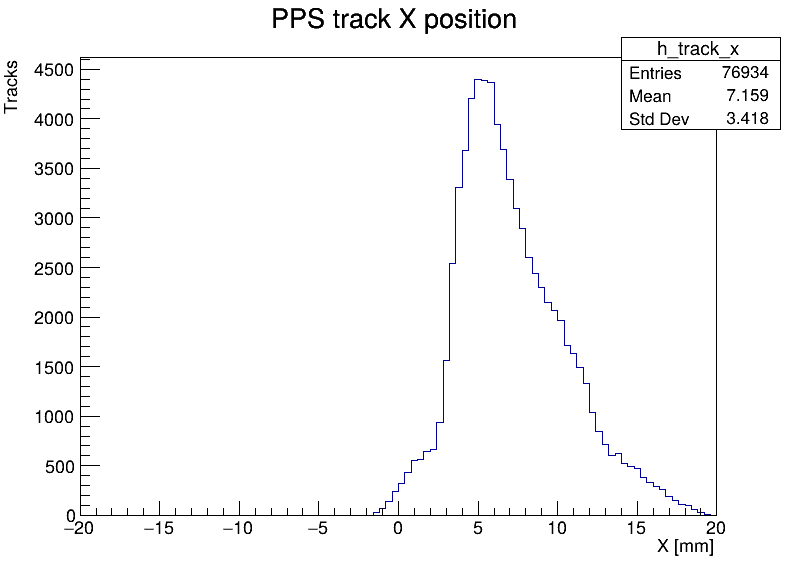

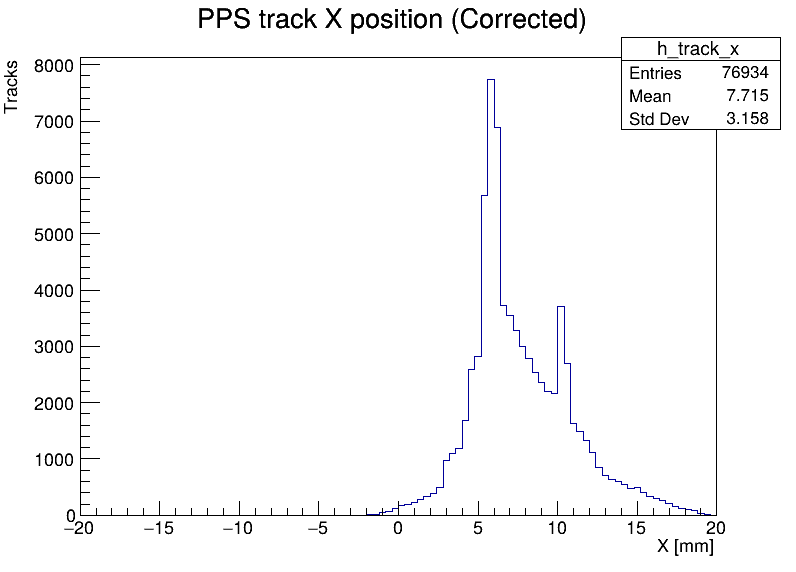

In [20]:
# Display before/after plots side by side (stacked here for simplicity).
display(Image(filename="data/pps_original_track_x.png"))
display(Image(filename="data/pps_corrected_track_x.png"))


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: filter_double_arm_events
  Events after filter: 276737
Applying filter 2: <lambda>
  Events after filter: 121461

=== Filter Results ===
Events after all filters: 121461

=== Creating Histograms ===
Creating histogram for: Proton_multiRP_xi
Creating histogram for: Proton_singleRP_xi
Created 2 histogram(s)

Saving histograms to: data/pps_xi_range_0.05_0.2.root
Histograms saved!

=== Creating Plots ===
Saved: data/pps_xi_range_0.05_0.2_proton_multi_rp_xi.png
Saved: data/pps_xi_range_0.05_0.2_proton_single_rp_xi.png

=== Histogram Creation Complete ===


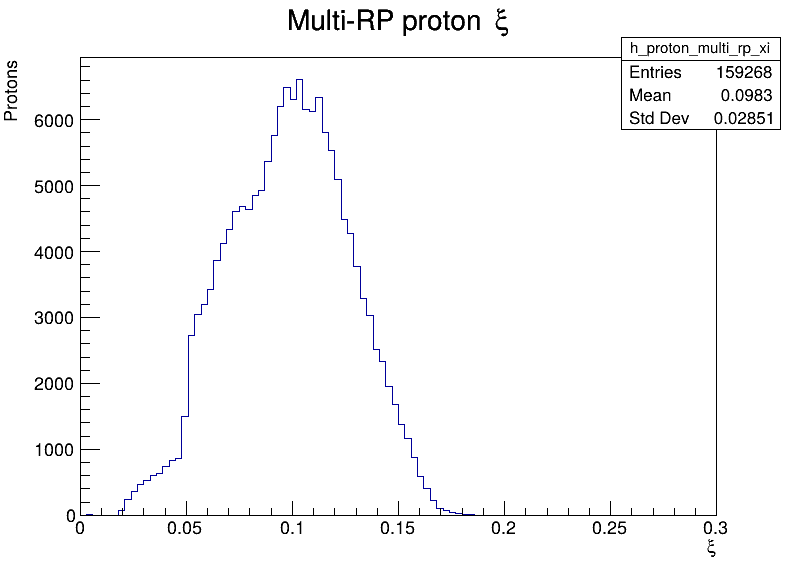

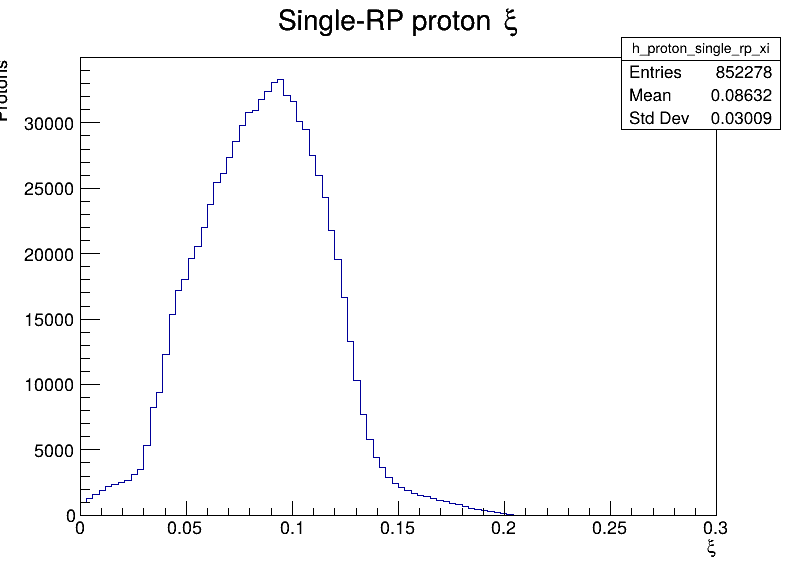

In [21]:
filters_a = [
    filter_double_arm_events,
    lambda df: filter_xi_ranged_events(df, 0.05, 0.2),
]
df_a = rdata_analysis(FILE_PATH, filters_a)

hists_a = create_histograms_and_plots(
    df_a,
    [PPSHistogramType.PROTON_MULTI_RP_XI, PPSHistogramType.PROTON_SINGLE_RP_XI],
    output_prefix="pps_xi_range_0.05_0.2",
)
for name in hists_a:
    display(Image(filename=f"data/pps_xi_range_0.05_0.2_{name}.png"))


### Recipe B — Pixel-detector tracks, XY correlation

Selects only events with tracks in silicon pixel detectors (RP 3, 23, 103,
123) and plots the X, Y, and 2D X-vs-Y track position distributions.


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: <lambda>
  Events after filter: 311565

=== Filter Results ===
Events after all filters: 311565

=== Creating Histograms ===
Creating histogram for: PPSLocalTrack_x
Creating histogram for: PPSLocalTrack_y
Creating histogram for: PPSLocalTrack_decRPId
Creating 2D histogram: X vs Y
Created 4 histogram(s)

Saving histograms to: data/pps_pixel_detectors.root
Histograms saved!

=== Creating Plots ===
Saved: data/pps_pixel_detectors_track_x.png
Saved: data/pps_pixel_detectors_track_y.png
Saved: data/pps_pixel_detectors_dec_rp_id.png
Saved: data/pps_pixel_detectors_xy.png

=== Histogram Creation Complete ===


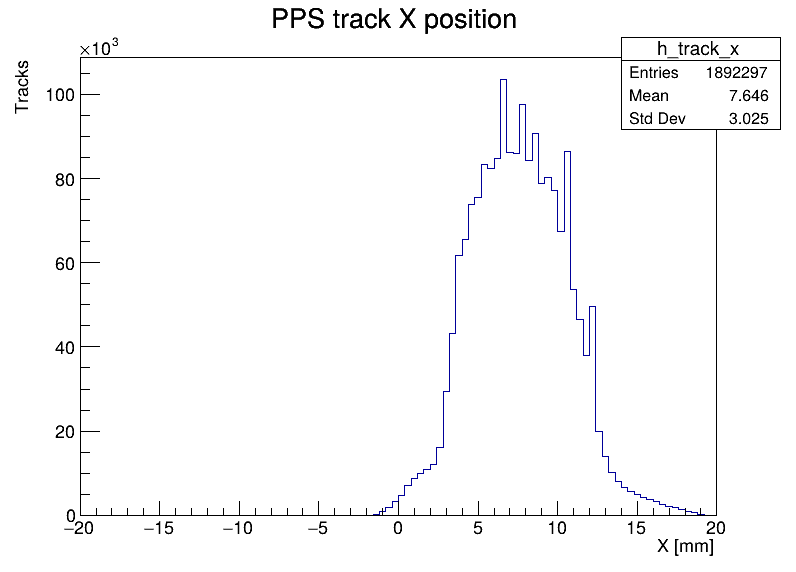

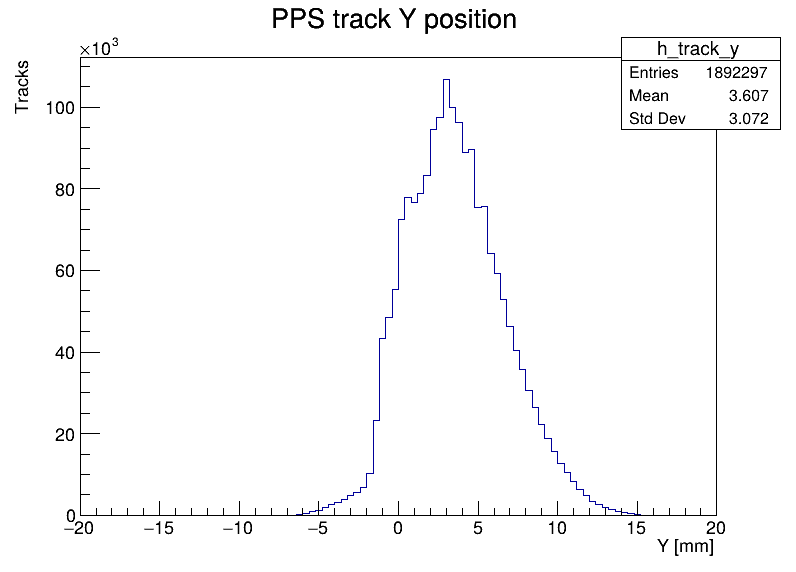

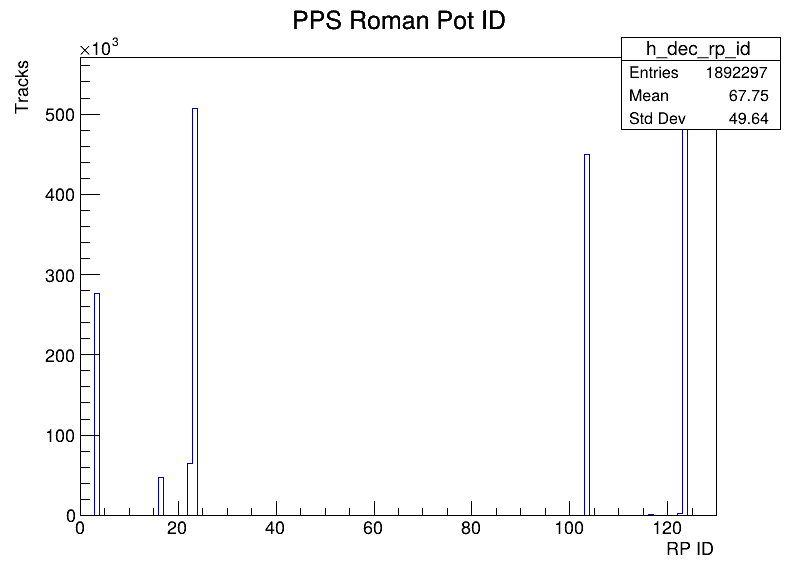

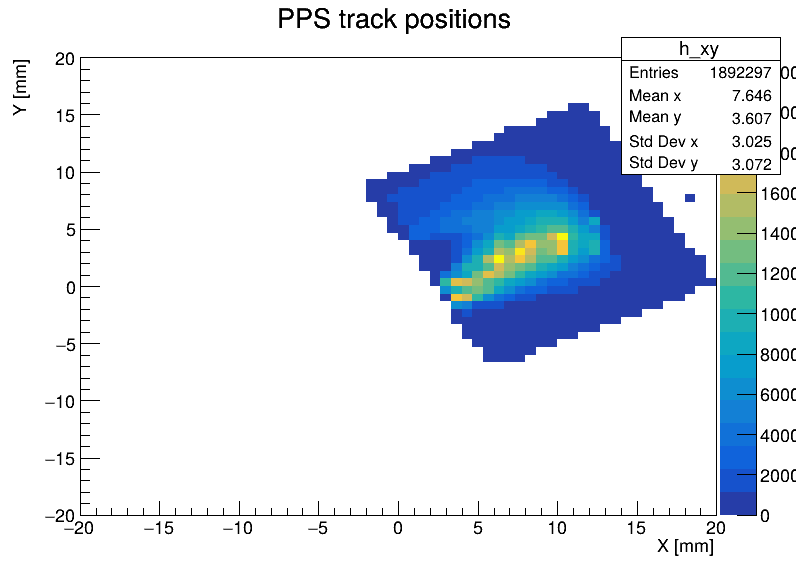

In [22]:
filters_b = [lambda df: filter_detector_type(df, "pixel")]
df_b = rdata_analysis(FILE_PATH, filters_b)

hists_b = create_histograms_and_plots(
    df_b,
    [
        PPSHistogramType.PPS_LOCAL_TRACK_X,
        PPSHistogramType.PPS_LOCAL_TRACK_Y,
        PPSHistogramType.PPS_LOCAL_TRACK_DEC_RP_ID,
    ],
    output_prefix="pps_pixel_detectors",
)
for name in hists_b:
    display(Image(filename=f"data/pps_pixel_detectors_{name}.png"))


In [23]:
df_c = rdata_analysis(FILE_PATH)

hists_c = create_histograms_and_plots(
    df_c,
    list(PPSHistogramType),
    output_prefix="pps_complete_analysis",
)
print(f"Generated {len(hists_c)} histograms — see the data/ directory for all PNGs.")


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Creating Histograms ===
Creating histogram for: HLT_DiPFJetAve180_PPSMatch_Xi0p3_QuadJet_Max2ProtPerRP
Creating histogram for: HLT_PPSMaxTracksPerArm1
Creating histogram for: HLT_PPSMaxTracksPerRP4
Creating histogram for: HLT_PPSRandom
Creating histogram for: nPPSLocalTrack
Creating histogram for: PPSLocalTrack_x
Creating histogram for: PPSLocalTrack_y
Creating histogram for: PPSLocalTrack_decRPId
Creating histogram for: PPSLocalTrack_rpType
Creating histogram for: PPSLocalTrack_multiRPProtonIdx
Creating histogram for: PPSLocalTrack_singleRPProtonIdx
Creating histogram for: PPSLocalTrack_time
Creating histogram for: PPSLocalTrack_timeUnc
Creating histogram for: nProton_multiRP
Creating histogram for: Proton_multiRP_arm
Creating histogram for: Proton_multiRP_t
Creating histogram for: Proton_multiRP_thetaX
Creating histogram for: Proton_multiRP_thetaY
Creatin

=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: <lambda>
  Events after filter: 218743

=== Filter Results ===
Events after all filters: 218743

=== Applying Corrections with correctionlib ===
Loading: corrections-examples/x_track_range_correction.json
✓ Loaded correction: track_position_correction
Extracting data from RDataFrame...
  Processed 5000/218743 events...
  Processed 10000/218743 events...
  Processed 15000/218743 events...
  Processed 20000/218743 events...
  Processed 25000/218743 events...
  Processed 30000/218743 events...
  Processed 35000/218743 events...
  Processed 40000/218743 events...
  Processed 45000/218743 events...
  Processed 50000/218743 events...
  Processed 55000/218743 events...
  Processed 60000/218743 events...
  Processed 65000/218743 events...
  Processed 70000/218743 events...
  Processed 75000/218743 events...
  Processed

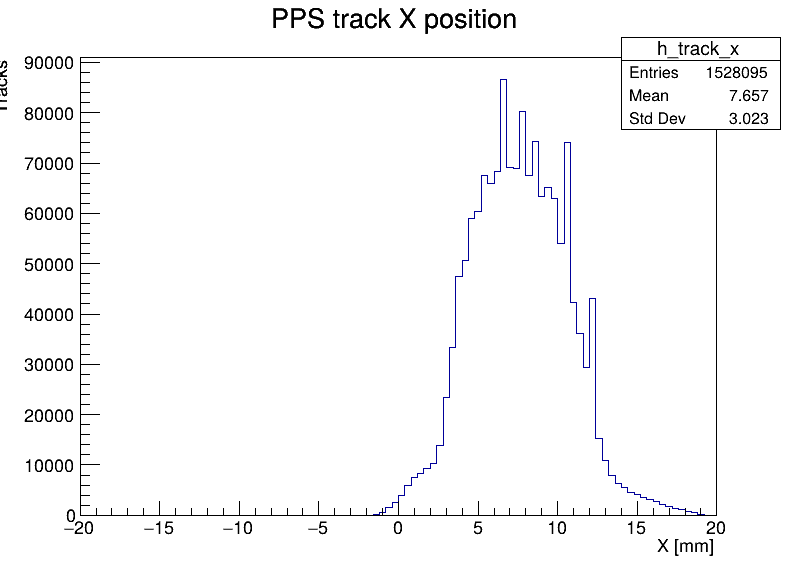

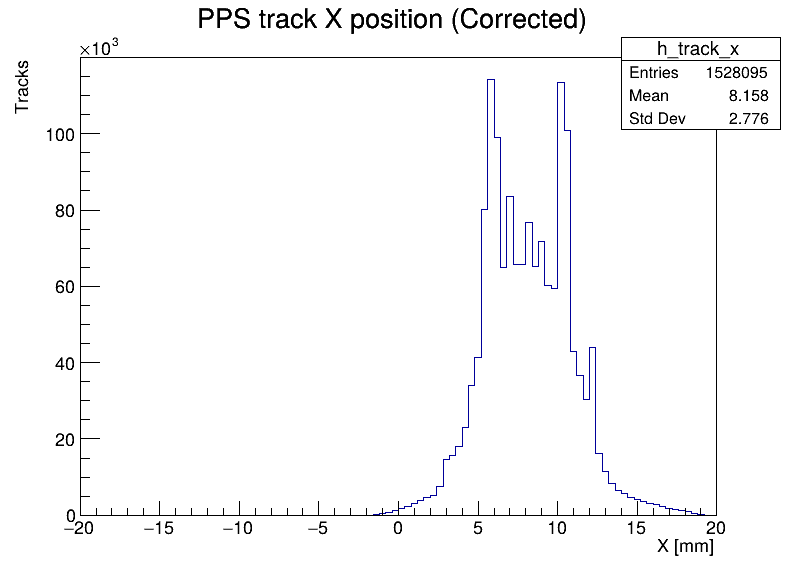

In [24]:
df_d = rdata_analysis(FILE_PATH, [lambda df: filter_detector_specific_events(df, 23)])

df_d_corrected, in_col, out_col = apply_corrections_hybrid(
    df_d, "corrections-examples/x_track_range_correction.json"
)

create_histograms_and_plots(
    df_d_corrected, [PPSHistogramType.PPS_LOCAL_TRACK_X],
    output_prefix="pps_rp23_original", corrections=False, save_root=False,
)
create_histograms_and_plots(
    df_d_corrected, [PPSHistogramType.PPS_LOCAL_TRACK_X],
    output_prefix="pps_rp23_corrected", corrections=True, save_root=False,
)

display(Image(filename="data/pps_rp23_original_track_x.png"))
display(Image(filename="data/pps_rp23_corrected_track_x.png"))
